In [2]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(
    lambda skill_list: ast.literal_eval(skill_list) if isinstance(skill_list, str) else skill_list
)

c:\Users\DELL\anaconda3\envs\data_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### US analysis

In [3]:
df_DE_us = df[(df['job_title_short'] == 'Data Engineer') & (df['job_country'] == 'United States')].copy()
df_DA_us = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DS_us = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].copy()

In [4]:
df_DA_us['job_posted_month_no'] = df_DA_us['job_posted_date'].dt.month
df_DE_us['job_posted_month_no'] = df_DE_us['job_posted_date'].dt.month
df_DS_us['job_posted_month_no'] = df_DS_us['job_posted_date'].dt.month

In [5]:
df_DA_us_explode = df_DA_us.explode('job_skills')
df_DE_us_explode = df_DE_us.explode('job_skills')
df_DS_us_explode = df_DS_us.explode('job_skills')

In [6]:
#Creates a pivot table showing how many times each skill appears in each month
df_DA_pivot = df_DA_us_explode.pivot_table(
    index='job_posted_month_no',
    columns='job_skills', 
    aggfunc='size', 
    fill_value=0
    )

df_DA_pivot.loc['Total'] = df_DA_pivot.sum()

#Sorts the columns (skills) by total popularity (descending order).
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_pivot = df_DA_pivot.drop('Total')
df_DA_pivot

job_skills,sql,excel,tableau,python,sas,r,power bi,word,powerpoint,oracle,...,capacitor,chainer,asp.net core,qt,microsoft lists,msaccess,kotlin,openstack,theano,xamarin
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,4601,3592,2488,2254,1832,1513,1337,968,972,718,...,1,0,0,0,0,0,0,0,0,0
2,3168,2587,1676,1618,1212,1045,1122,738,705,514,...,0,0,0,0,0,0,0,0,0,0
3,3226,2661,1804,1683,1238,1141,1054,736,669,418,...,0,0,0,0,0,0,0,0,0,1
4,3220,2549,1789,1679,1302,1038,1057,695,650,439,...,0,0,0,0,0,0,0,0,0,0
5,2581,2118,1432,1349,972,867,860,557,515,358,...,0,0,0,0,0,1,0,0,0,0
6,2862,2382,1628,1609,984,1017,989,721,624,414,...,0,0,0,1,0,0,1,1,0,0
7,2609,2118,1533,1438,996,881,881,587,549,401,...,0,0,0,0,0,0,0,0,0,0
8,3414,2731,1951,2025,1276,1271,1208,752,746,484,...,0,0,0,0,0,0,0,0,0,0
9,2295,1801,1353,1229,856,746,820,478,475,359,...,0,0,0,0,0,0,0,0,0,0


In [7]:
#Creates a pivot table showing how many times each skill appears in each month
df_DE_pivot = df_DE_us_explode.pivot_table(
    index='job_posted_month_no',
    columns='job_skills', 
    aggfunc='size', 
    fill_value=0
    )

df_DE_pivot.loc['Total'] = df_DE_pivot.sum()

#Sorts the columns (skills) by total popularity (descending order).
df_DE_pivot = df_DE_pivot[df_DE_pivot.loc['Total'].sort_values(ascending=False).index]

df_DE_pivot = df_DE_pivot.drop('Total')
df_DE_pivot

job_skills,sql,python,aws,azure,spark,java,snowflake,hadoop,kafka,scala,...,lisp,fastify,qt,powerbi,mlpack,sqlserver,svelte,workfront,xamarin,wrike
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,1826,1745,1119,841,916,695,592,515,547,517,...,0,0,0,0,0,0,0,0,0,0
2,2109,2043,1415,965,1063,829,763,645,647,597,...,1,0,0,0,0,0,0,0,0,0
3,2204,2126,1472,1023,1038,791,704,640,605,587,...,0,0,0,0,0,0,0,0,0,0
4,1914,1868,1222,937,878,682,676,498,514,534,...,0,0,0,0,0,0,0,0,0,0
5,2077,2023,1252,990,952,730,681,529,491,509,...,0,0,0,0,0,0,0,0,1,0
6,2048,1882,1260,947,955,686,668,516,495,459,...,0,0,0,0,0,0,0,0,0,0
7,1789,1689,1166,794,821,615,624,483,448,461,...,1,0,1,0,0,0,0,1,0,0
8,2246,2155,1388,1003,1006,754,749,594,565,557,...,0,0,0,0,0,1,1,0,0,0
9,2090,1934,1267,960,941,671,700,479,500,483,...,0,0,0,1,0,0,0,0,0,0


In [8]:
#Creates a pivot table showing how many times each skill appears in each month
df_DS_pivot = df_DS_us_explode.pivot_table(
    index='job_posted_month_no',
    columns='job_skills', 
    aggfunc='size', 
    fill_value=0
    )

df_DS_pivot.loc['Total'] = df_DS_pivot.sum()

#Sorts the columns (skills) by total popularity (descending order).
df_DS_pivot = df_DS_pivot[df_DS_pivot.loc['Total'].sort_values(ascending=False).index]

df_DS_pivot = df_DS_pivot.drop('Total')
df_DS_pivot

job_skills,python,sql,r,sas,tableau,aws,spark,java,tensorflow,azure,...,asp.net core,clickup,couchdb,fedora,ocaml,mattermost,nuix,shogun,symfony,wrike
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,5243,3770,3362,1700,1630,1364,1356,916,896,817,...,1,1,1,0,0,0,1,0,1,0
2,3718,2670,2334,1144,1268,854,895,645,565,573,...,0,0,0,0,0,0,0,0,0,0
3,3394,2426,2189,1144,1126,848,787,575,529,538,...,0,0,0,0,0,0,0,1,0,0
4,3622,2463,2181,1204,1213,882,823,622,582,538,...,0,0,0,0,0,0,0,0,0,0
5,3232,2293,2016,1150,1174,797,774,629,517,521,...,0,0,0,0,0,0,0,0,0,0
6,3431,2442,2107,1158,1135,818,822,586,537,568,...,0,0,0,0,0,0,0,0,0,1
7,3541,2479,2210,1106,1223,860,802,581,570,607,...,0,0,0,1,0,0,0,0,0,0
8,4566,3324,2896,1598,1520,1076,1075,767,809,727,...,0,0,0,0,0,0,0,0,0,0
9,3112,2155,1791,1158,921,697,740,534,567,558,...,0,0,0,0,0,0,0,0,0,0


In [9]:
da_total = df_DA_us.groupby('job_posted_month_no').size()
de_total = df_DE_us.groupby('job_posted_month_no').size()
ds_total = df_DS_us.groupby('job_posted_month_no').size()

In [10]:
df_DA_us_percent = df_DA_pivot.div(da_total / 100, axis=0)
df_DE_us_percent = df_DE_pivot.div(de_total / 100, axis=0)
df_DS_us_percent = df_DS_pivot.div(ds_total / 100, axis=0)

### For Data Analyst roles

In [11]:
df_DA_us_percent = df_DA_us_percent.reset_index()
df_DA_us_percent['job_posted_month'] = df_DA_us_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_us_percent = df_DA_us_percent.set_index('job_posted_month')
df_DA_us_percent = df_DA_us_percent.drop(columns='job_posted_month_no')

df_DA_us_percent

job_skills,sql,excel,tableau,python,sas,r,power bi,word,powerpoint,oracle,...,capacitor,chainer,asp.net core,qt,microsoft lists,msaccess,kotlin,openstack,theano,xamarin
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,54.167648,42.288674,29.291264,26.536379,21.568166,17.812574,15.740523,11.396280,11.443372,8.453026,...,0.011773,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,51.730895,42.243632,27.367734,26.420640,19.790986,17.064010,18.321359,12.050947,11.512084,8.393207,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,51.881634,42.795111,29.012544,27.066581,19.909939,18.349952,16.950788,11.836603,10.759087,6.722419,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016082
Apr,53.231939,42.139197,29.575136,27.756654,21.524219,17.159861,17.473963,11.489502,10.745578,7.257398,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,51.692369,42.419387,28.680152,27.017825,19.467254,17.364310,17.224114,11.155618,10.314440,7.170038,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.020028,0.000000,0.000000,0.000000,0.000000
Jun,50.360725,41.914482,28.646841,28.312511,17.314799,17.895478,17.402780,12.686961,10.980116,7.284885,...,0.000000,0.000000,0.000000,0.017596,0.000000,0.000000,0.017596,0.017596,0.000000,0.000000
Jul,50.163430,40.722938,29.475101,27.648529,19.150163,16.939050,16.939050,11.286291,10.555662,7.710056,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,51.462165,41.166717,29.409105,30.524570,19.234248,19.158879,18.209225,11.335544,11.245101,7.295749,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,49.471869,38.823022,29.165768,26.492779,18.452253,16.081052,17.676223,10.303945,10.239276,7.738737,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


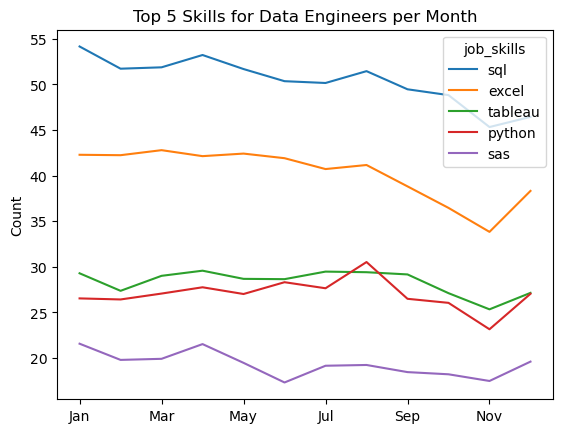

In [15]:
df_DA_us_percent.iloc[:, :5].plot(kind='line')

plt.title('Top 5 Skills for Data Engineers per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()


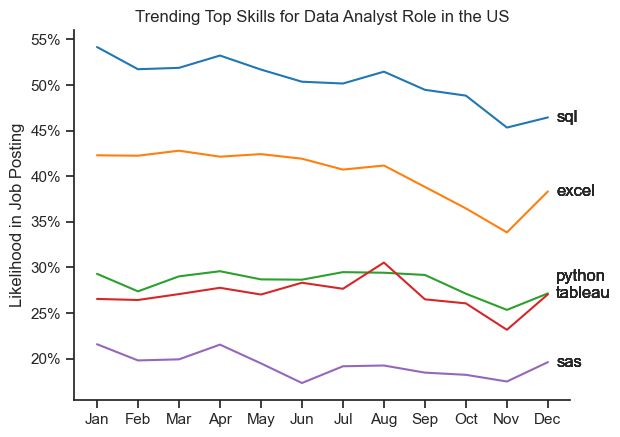

In [36]:
df_DA_plot = df_DA_us_percent.iloc[:, :5]
sns.lineplot(data=df_DA_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()
plt.title('Trending Top Skills for Data Analyst Role in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax= plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

last_x = df_DA_plot.index[-1]
used_y = []

for i in range(5):
    last_x = df_DA_plot.index[-1]
    used_y = []

    for i in range(5):
        y = df_DA_plot.iloc[-1, i]

    # Avoid overlap by nudging if too close to another label
        while any(abs(y - used) < 1.5 for used in used_y):
            y += 1  # nudge up slightly

        used_y.append(y)

        plt.text(11.2, y, df_DA_plot.columns[i], va='center')